In [9]:
# command to auto-reload modules when they are edited (easier for testing and debugging)
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import healpix_geo 
import numpy as np
from foscat.Plot import lgnomproject
import matplotlib.pyplot as plt

level=15
ilevel=14
ndata=128
cell_ids=3*4**ilevel+np.arange(ndata*ndata)
lon,lat = healpix_geo.nested.healpix_to_lonlat(cell_ids, ilevel,ellipsoid='WGS84')
val=lon

In [11]:
from regrid_to_healpix.regrid_to_healpix_bilinear import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val,lam=0.1)  # selon ton API
rval     = nr.invert(hval)
cell_ids = nr.get_cell_ids()
hval.shape,rval.shape

((65536,), (16384,))

np.float64(7.356127941185935e-28)

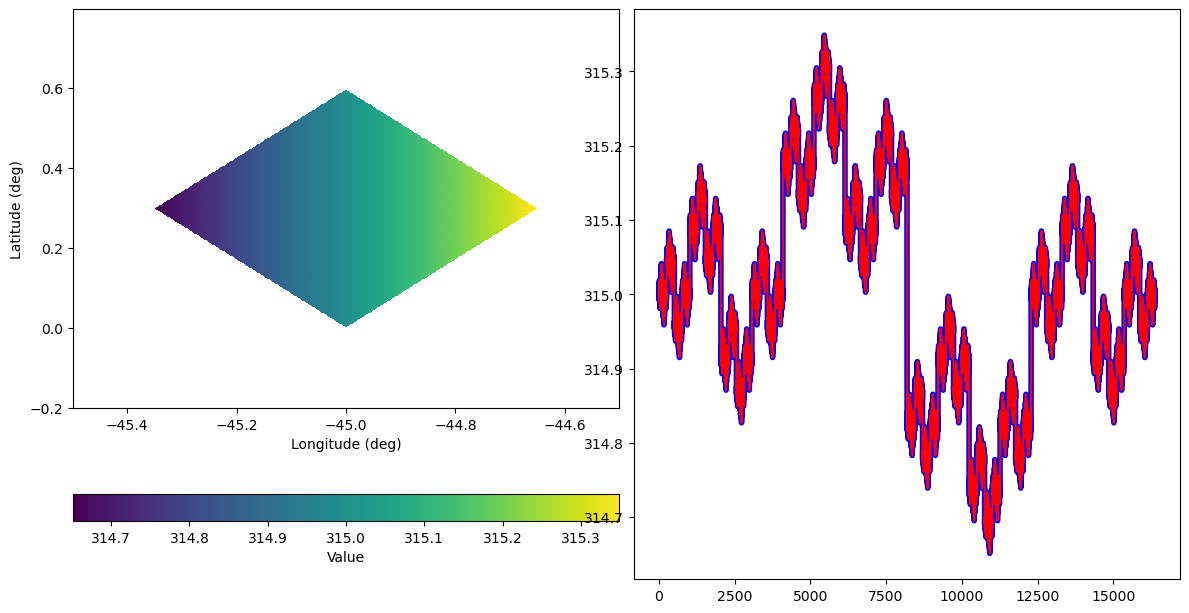

In [12]:
plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval,2**(level),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)

In [13]:
from regrid_to_healpix.regrid_to_healpix_psf import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val,lam=0.1)  # selon ton API
rval     = nr.invert(hval)
cell_ids = nr.get_cell_ids()
hval.shape,rval.shape

Itt 0 : 7.458e-09
Itt 4 : 1.92e-21
Final Itt 5 : 1.407e-24


((65536,), (16384,))

np.float64(1.0105651392775887e-12)

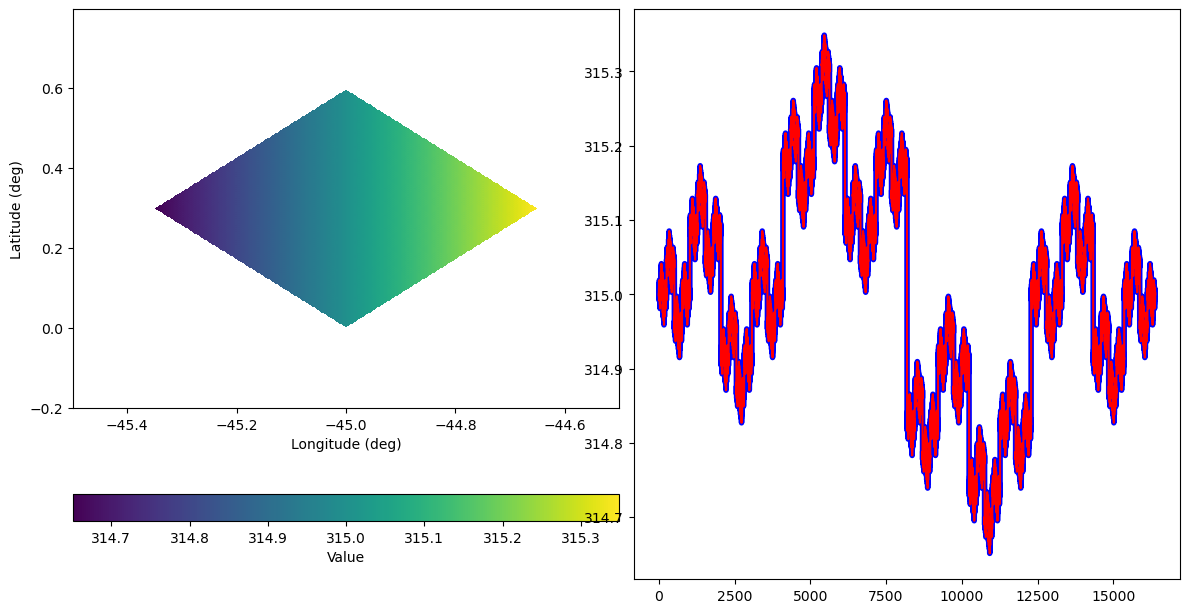

In [14]:
plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval,2**(level),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)

In [15]:
from regrid_to_healpix.regrid_to_healpix_nearest import Set

nr = Set(lon_deg=lon, lat_deg=lat, level=level)  # Npt=1 imposé dans nearest
# puis:
hval     = nr.transform(val)  # selon ton API
rval     = nr.invert(hval)
cell_ids = nr.get_cell_ids()
hval.shape,rval.shape

((16384,), (16384,))

np.float64(0.0)

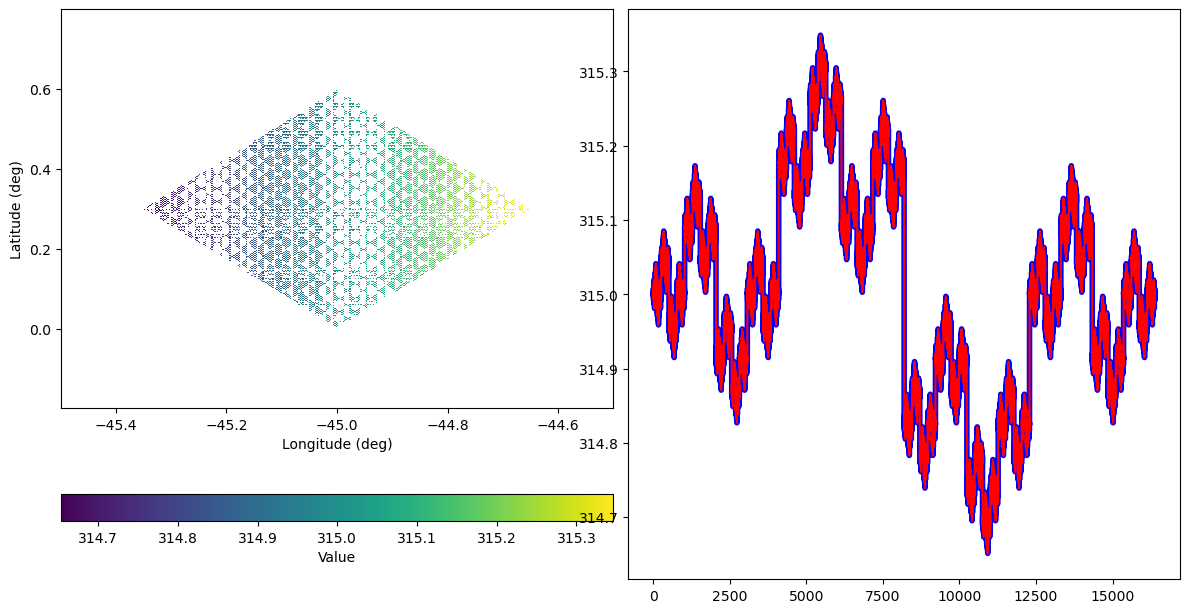

In [16]:

plt.figure(figsize=(12,6))
lgnomproject(cell_ids,hval,2**(level),hold=False,fov_deg=1,interp=False,sub=(1,2,1),cbar=True)
plt.subplot(1,2,2)
plt.plot(lon,color='b',lw=4)
plt.plot(rval,color='r')
np.mean((rval-lon)**2)